# Held-out NL→FOL faithfulness test set: building and source-verifying the final file

This notebook demos **`data.py`**, the final step that builds `full_data_out.json` for a **held-out meta-evaluation set for NL→FOL (natural language → first-order logic) faithfulness metrics**.

**What the dataset is.** Each row pairs a sentence with a *real* candidate FOL formula from one of several systems. The systems are 10 LLM slots across 9 model families, GPT-5.1, the symbolic ccg2lambda parser, and the MALLS GPT-4 gold treated as a system. Each row has a faithfulness label: `CORRECT` / `ERROR` / `CONTESTED` / `UNRESOLVED` / `UNPARSEABLE`. Labels combine a z3 solver equivalence check against the reference with a blind, family-disjoint LLM panel (Haiku-4.5 / GLM-4.6 / Kimi-K2). The combination rule assigns a trust tier:
- **tier A**: decided by the solver;
- **tier B**: panel-decided vocabulary/granularity or compound cases;
- **tier C**: no trusted reference.

The full set has 700 held-out sentences in the strata L25 (≥25 words, ≥3 conditions), L20, EXC (unless/except/without) and CTRL (FOLIO), with 8,507 candidate rows in total.

**What `data.py` does.** It does not call any model. It takes the already-labelled groups (`work/assembled.json`) and **re-verifies every row against the public source datasets**:
- the sentence and reference must match the MALLS-v0.1 train record, or the FOLIO-v2 train premise plus its folio-refined formula;
- LLM candidates must match the stored raw generation;
- ccg2lambda candidates must match a `folio_by_ccg2lambda` logical form;
- the MALLS-gold "system" must equal the gold.

It records `metadata_source_verified` and `metadata_source_file` on each row. Then it checks the output schema and writes the full, mini and preview files.

**What this demo runs.** It uses a curated subset: every candidate row (92) for 7 held-out sentences from the `heldout_candidates` group, covering all 4 strata and all 5 labels. `mini_demo_data.json` embeds the matching slices of the source datasets, so the original verification code runs unchanged offline and on Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, pyarrow, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

import csv
import json
import re
import shutil
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
from loguru import logger

# additional imports for the notebook's results section
import matplotlib.pyplot as plt
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})
print({k: (len(v) if isinstance(v, list) else {m: len(x) for m, x in v.items()}) for k, v in data["sources"].items()})

{'heldout_candidates': 92}
{'malls_v0_1_train': 5, 'folio_v2_train': 6, 'folio_refined_train': 6, 'folio_refined_validation': 0, 'generations': 92, 'ccg2lambda_train_logical_form': 1, 'curated_folio_validation': 0, 'curated_malls_test': 0, 'logiclm_folio_dev': {'gpt-3.5-turbo': 0, 'gpt-4': 0, 'text-davinci-003': 0}}


## Configuration

`data.py` has no training loop or sampling. Its only size knobs are how many rows it processes, the number of rows kept in the mini/preview files, the preview's string truncation length and the per-file size limit.
- `N_EXAMPLES`: how many of the demo's `heldout_candidates` rows to verify. `None` means all 92 rows in `mini_demo_data.json`. The original runs all 8,507 held-out candidates plus the other 3 groups, about 10.5k rows in total.
- `MINI_K`: examples per group in `mini_data_out.json` (original default `k=3`).
- `TRUNC_N`: string truncation length in `preview_data_out.json` (original default `n=200`).
- `LIMIT`: per-file size limit. Above it the output is split into `full_data_out/full_data_out_{i}.json` parts (original: 100 MB).
- `ROOT`: output folder. The original writes next to `data.py`; here the demo writes to `demo_out/`.

In [5]:
N_EXAMPLES = None          # None = all rows in mini_demo_data.json (92); original: every row of full_data_out (8,507 + 700 + 173 + 1,173)
MINI_K = 3                 # original: mini(obj, k=3)
TRUNC_N = 200              # original: trunc(x, n=200)
LIMIT = 100 * 1000 * 1000  # aii-file-size-limit: 100 MB per file (original value)
ROOT = Path("demo_out")    # original: ROOT = Path(__file__).resolve().parent

## Setup: logging and constants

These lines are the same as in `data.py`, except that `ROOT` comes from the config cell. `TD` (the `temp/datasets` symlink folder) is left out, because the sources come from `data["sources"]`. `GROUP_ORDER` is the fixed order of the 4 groups in the full file. `FORBIDDEN` lists keys that the pipeline schema does not allow in a row.

In [6]:
ROOT.mkdir(exist_ok=True)
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

GROUP_ORDER = ["heldout_candidates", "heldout_sentences", "panel_calibration", "screen_audit"]
FORBIDDEN = {"split", "dataset", "context"}


def ws(s: str | None) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Loading the source datasets

`load_sources()` builds the lookup tables that rows are checked against. All comparisons use whitespace-normalised strings (`ws`).
- `malls_train`: MALLS-v0.1 train, mapping NL to its gold FOL.
- `folio_train_premises`: every FOLIO-v2 train premise sentence (the CTRL stratum).
- `refined_train_fols` / `refined_train_pairs`: folio-refined train formulas, and (NL, FOL) pairs where the premise lists line up.
- `gens`: the raw LLM outputs, keyed by `(sentence_id, slot, prompt_variant)`.
- `ccg_forms`: ccg2lambda logical forms.
- `curated` and `logiclm_lines`: only used by the `screen_audit` and `panel_calibration` groups, which this demo subset leaves out.

**The only change from `data.py`**: each `open(file)` / `read_jsonl(file)` / `pd.read_parquet(file)` now reads the matching slice embedded in `data["sources"]`. The dict and set construction is unchanged.

In [7]:
def load_sources() -> dict:
    S = data["sources"]  # demo: embedded slices replace the files under temp/datasets/
    src = {}
    src["malls_train"] = {ws(r["NL"]): ws(r["FOL"]) for r in S["malls_v0_1_train"]}
    src["folio_train_premises"] = {ws(p) for r in S["folio_v2_train"] for p in r["premises"].split("\n")}
    refined, refined_pairs = set(), set()
    for r in S["folio_refined_train"]:
        nls = [s for s in r["nl premises"].split("\n") if s.strip()]
        fols = [s for s in r["fol premises"].split("\n") if s.strip()]
        refined |= {ws(f) for f in fols}
        if len(nls) == len(fols):
            refined_pairs |= {(ws(n), ws(f)) for n, f in zip(nls, fols)}
    src["refined_train_fols"], src["refined_train_pairs"] = refined, refined_pairs
    src["refined_val_fols"] = {ws(f) for r in S["folio_refined_validation"] for f in r["fol premises"].split("\n") if f.strip()}
    src["gens"] = {(g["sentence_id"], g["slot"], g["prompt_variant"]): g["raw_output"]
                   for g in S["generations"] if g.get("raw_output") is not None}
    df = pd.DataFrame({"logical_form": S["ccg2lambda_train_logical_form"]})
    src["ccg_forms"] = {ws(x) for x in df["logical_form"]}
    cur = {}
    for rows, newk, f in [(S["curated_folio_validation"], "FOL_sentence", "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl"),
                          (S["curated_malls_test"], "FOL_sentence_new", "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl")]:
        for r in rows:
            cur[str(r["id"])] = (ws(r["NL_sentence"]), ws(r["FOL_sentence_old"]), ws(r[newk]), f)
    src["curated"] = cur
    src["curated_corrected_fols"] = {v[2] for v in cur.values()}
    lines = set()
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in S["logiclm_folio_dev"][m]:
            prog = r["raw_logic_programs"][0] if isinstance(r["raw_logic_programs"], list) else r["raw_logic_programs"]
            for line in prog.splitlines():
                if ":::" in line:
                    fol, nl = line.strip().split(":::", 1)
                    lines.add((m, ws(fol), ws(nl)))
    src["logiclm_lines"] = lines
    return src

## Per-row source verification

These three functions are copied unchanged from `data.py`.

**`verify_heldout`** checks the held-out rows.
- *Reference side:* CTRL rows must be a FOLIO-v2 train premise whose reference formula is in folio-refined train. MALLS rows (L25/L20/EXC) must match the MALLS train gold. The one exception is a reference the panel **repaired** (`PANEL_REPAIRED`), which is expected to differ from the gold.
- *Candidate side*, by system:
  - `malls_gpt4_gold` must equal the gold;
  - `ccg2lambda` must be a published ccg2lambda logical form;
  - an LLM candidate's raw output must equal the stored generation for `(sentence_id, slot, prompt_variant)`.

**`verify_screen`** and **`verify_calib`** check the `screen_audit` and `panel_calibration` groups, against the Logic-LM outputs and the DSAVlab-UNIUD expert-curated records. They are defined here for completeness, but this demo subset has no rows from those groups.

In [8]:
def verify_heldout(ex: dict, src: dict, sentence_row: bool = False) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    text = ws(inp["text"])
    stratum = ex["metadata_strata"]["source_stratum"]
    orig_ref = ws(ex.get("metadata_original_reference_fol") or inp["reference_fol"]) if sentence_row else None
    if stratum == "CTRL":
        ref = ws(inp["reference_fol"])
        ok = text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"])
        file = "tasksource__folio/folio_v2_train.jsonl + local_sources/yfxiao__folio-refined__train.csv"
    else:
        gold = src["malls_train"].get(text)
        ref = orig_ref if sentence_row else ws(inp["reference_fol"])
        ok = gold is not None and (ref == gold or ex.get("metadata_reference_status") == "PANEL_REPAIRED")
        file = "local_sources/yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
    if sentence_row or not ok:
        return ok, file
    sys_ = ex["metadata_system"]
    if sys_ == "malls_gpt4_gold":
        return ws(inp["candidate_fol"]) == src["malls_train"].get(text), file
    if sys_ == "ccg2lambda":
        return ws(ex["metadata_raw_output"]) in src["ccg_forms"], file + " + kenken6696__folio_by_ccg2lambda/train"
    raw = src["gens"].get((ex["metadata_sentence_id"], ex["metadata_slot"], ex["metadata_prompt_variant"]))
    return raw is not None and raw == ex["metadata_raw_output"], file + " + generated_candidates/generations.jsonl"


def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_track"] == "H":
        c = src["curated"].get(str(ex["metadata_record_id"]))
        ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["candidate_fol"]) and c[2] == ws(inp["reference_fol"])
        return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"
    ok_line = (ex["metadata_system"], ws(inp["candidate_fol"]), ws(inp["text"])) in src["logiclm_lines"]
    ref = ws(inp["reference_fol"])
    ok_ref = ref in src["curated_corrected_fols"] or ref in src["refined_val_fols"]
    return ok_line and ok_ref, f"logiclm_FOLIO_dev_outputs/FOLIO_dev_{ex['metadata_system']}.json"


def verify_calib(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_subset"] == "synthetic_gate":
        text, ref = ws(inp["text"]), ws(inp["reference_fol"])
        return text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"]), \
            "local_sources/yfxiao__folio-refined__train.csv"
    c = src["curated"].get(str(ex["metadata_record_id"]))
    ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["original_fol"]) and c[2] == ws(inp["corrected_fol"])
    return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"

## Schema check and output writers

These helpers are unchanged from `data.py`, except that the `k`/`n` defaults now come from the config cell.
- `check_schema` enforces the pipeline's `exp_sel_data_out` layout: `datasets[].examples[]`, where each row has a string `input` and `output` plus only `metadata_*` keys.
- `mini` keeps the first `k` rows of each group.
- `trunc` cuts long strings for the preview file.
- `write_parts` splits the output into numbered part files if it is over `LIMIT`.

In [9]:
def check_schema(obj: dict) -> None:
    assert isinstance(obj.get("datasets"), list) and obj["datasets"]
    for d in obj["datasets"]:
        assert set(d) == {"dataset", "examples"} and d["examples"], d.get("dataset")
        for ex in d["examples"]:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str)
            for k in ex:
                assert k in ("input", "output") or (k.startswith("metadata_") and re.fullmatch(r"metadata_[a-zA-Z_][a-zA-Z0-9_]*", k)), k
                assert k not in FORBIDDEN


def trunc(x, n=TRUNC_N):
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(v, n) for v in x]
    if isinstance(x, dict):
        return {k: trunc(v, n) for k, v in x.items()}
    return x


def mini(obj, k=MINI_K):
    return {"metadata": obj.get("metadata", {}), "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:k]} for d in obj["datasets"]]}


def write_parts(obj: dict) -> list[Path]:
    out = ROOT / "full_data_out"
    if out.exists():
        shutil.rmtree(out)
    out.mkdir()
    parts, cur, size = [], [], 0
    for d in obj["datasets"]:
        chunk = []
        for ex in d["examples"]:
            sz = len(json.dumps(ex, ensure_ascii=False).encode())
            if size + sz > LIMIT and (cur or chunk):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur); cur, chunk, size = [], [], 0
            chunk.append(ex); size += sz
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    paths = []
    for i, p in enumerate(parts, 1):
        o = {"metadata": {**obj["metadata"], "part": i, "n_parts": len(parts)}, "datasets": p}
        check_schema(o)
        f = out / f"full_data_out_{i}.json"
        f.write_text(json.dumps(o, ensure_ascii=False))
        (out / f"mini_full_data_out_{i}.json").write_text(json.dumps(mini(o), ensure_ascii=False, indent=1))
        (out / f"preview_full_data_out_{i}.json").write_text(json.dumps(trunc(mini(o)), ensure_ascii=False, indent=1))
        paths.append(f)
    m = mini(obj)
    (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
    return paths

## Main: verify every row, then write the output files

`main()` follows the original `data.py`, with three small changes for the demo:
1. `A` is the loaded demo `data`, cut to `N_EXAMPLES` rows, instead of `work/assembled.json`.
2. The group-order assertion and the verification loop only cover the groups present in the subset, which here is just `heldout_candidates`.
3. The `work/` folder is created under `ROOT`.

Nothing is ever dropped. Each row gets `metadata_source_verified` (True/False) and `metadata_source_file`, and the per-group report counts verified and unverified rows and tallies the labels.

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    A = {"metadata": data["metadata"], "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:N_EXAMPLES]} for d in data["datasets"]]}
    groups = {d["dataset"]: d["examples"] for d in A["datasets"]}
    assert list(groups) == [g for g in GROUP_ORDER if g in groups], list(groups)  # demo: subset holds only some groups
    src = load_sources()
    logger.info(f"sources loaded: MALLS-train {len(src['malls_train'])}, generations {len(src['gens'])}, Logic-LM lines {len(src['logiclm_lines'])}")
    report = {}
    for name, fn in [("heldout_candidates", lambda e: verify_heldout(e, src)),
                     ("heldout_sentences", lambda e: verify_heldout(e, src, sentence_row=True)),
                     ("panel_calibration", lambda e: verify_calib(e, src)),
                     ("screen_audit", lambda e: verify_screen(e, src))]:
        if name not in groups:  # demo: skip groups not in the subset
            continue
        c = Counter()
        for ex in groups[name]:
            ok, f = fn(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        report[name] = {"rows": len(groups[name]), "verified": c[True], "unverified": c[False],
                        "labels": dict(Counter(e["output"] for e in groups[name]))}
        logger.info(f"{name}: {report[name]}")
    obj = {"metadata": {**A["metadata"], "source_verification": report,
                        "reading": "for f in sorted(glob('full_data_out/full_data_out_*.json')): concatenate each group's examples"},
           "datasets": [{"dataset": g, "examples": groups[g]} for g in GROUP_ORDER if g in groups]}
    check_schema(obj)
    blob = json.dumps(obj, ensure_ascii=False)
    if len(blob.encode()) <= LIMIT:
        if (ROOT / "full_data_out").exists():
            shutil.rmtree(ROOT / "full_data_out")
        (ROOT / "full_data_out.json").write_text(blob)
        m = mini(obj)
        (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
        (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
        paths = [ROOT / "full_data_out.json"]
    else:
        (ROOT / "full_data_out.json").unlink(missing_ok=True)
        paths = write_parts(obj)
    for p in paths:
        logger.info(f"{p.relative_to(ROOT)} {p.stat().st_size / 1e6:.2f} MB")
    (ROOT / "work").mkdir(exist_ok=True)
    (ROOT / "work" / "source_verification.json").write_text(json.dumps(report, indent=1))

In [11]:
main()

12:44:45|INFO   |sources loaded: MALLS-train 5, generations 86, Logic-LM lines 0


12:44:45|INFO   |heldout_candidates: {'rows': 92, 'verified': 92, 'unverified': 0, 'labels': {'CONTESTED': 12, 'ERROR': 49, 'CORRECT': 19, 'UNPARSEABLE': 10, 'UNRESOLVED': 2}}


12:44:45|INFO   |full_data_out.json 0.27 MB


## Results

**1. Verification report and the written files.** Every row should verify: each sentence, reference and candidate traces back byte-for-byte to its public source or to the stored generation.

In [12]:
out = json.loads((ROOT / "full_data_out.json").read_text())
report = out["metadata"]["source_verification"]
print(pd.DataFrame(report).T[["rows", "verified", "unverified"]].to_string())
for p in sorted(ROOT.rglob("*.json")):
    print(f"  {p}  {p.stat().st_size / 1e3:.1f} KB")

rows = out["datasets"][0]["examples"]
df = pd.DataFrame([{
    "sentence_id": e["metadata_sentence_id"],
    "stratum": e["metadata_strata"]["source_stratum"],
    "words": e["metadata_strata"]["words"],
    "n_conditions": e["metadata_strata"]["n_conditions"],
    "ref_status": e["metadata_reference_status"],
    "system": e["metadata_system"].split(":")[-1].split("/")[-1] + (" (zero-shot)" if e["metadata_prompt_variant"].startswith("zeroshot") else ""),
    "label": e["output"],
    "tier": e["metadata_label_tier"],
    "verified": e["metadata_source_verified"],
    "error_ops": ",".join(e["metadata_error_ops"] or []),
} for e in rows])
print()
print(df.groupby(["sentence_id", "stratum", "words", "n_conditions", "ref_status"]).label.value_counts().unstack(fill_value=0).to_string())

                   rows verified unverified
heldout_candidates   92       92          0
  demo_out/full_data_out.json  268.7 KB
  demo_out/mini_data_out.json  11.9 KB
  demo_out/preview_data_out.json  10.4 KB


  demo_out/work/source_verification.json  0.2 KB



label                                                         CONTESTED  CORRECT  ERROR  UNPARSEABLE  UNRESOLVED
sentence_id  stratum words n_conditions ref_status                                                              
0028e3bae258 CTRL    16    2            DISPUTED_REFERENCE            0        3     10            1           0
0577037f035f L20     24    5            GOLD_PANEL_OK                 1        1      8            3           0
0b14d8cc7810 CTRL    13    1            DISPUTED_REFERENCE            2        5      3            1           1
0ef5da9c080c L25     32    4            NO_TRUSTED_REFERENCE          1        1      9            2           0
10f0945c15d5 L25     36    6            PANEL_REPAIRED                3        2      7            1           0
130558dca503 EXC     20    5            NO_TRUSTED_REFERENCE          4        1      7            1           1
439e4bdd3501 EXC     22    1            GOLD_PANEL_OK                 1        6      5         

**2. A sample of rows:** the sentence, the candidate, the reference and the final label. This shows what the meta-evaluation labels look like for long, heavily conditioned sentences.

In [13]:
for e in [r for r in rows if r["metadata_strata"]["source_stratum"] == "L25"][:4]:
    inp = json.loads(e["input"])
    print(f"[{e['output']:<11}] tier={e['metadata_label_tier']} system={e['metadata_system']}  error_ops={e['metadata_error_ops']}")
    print("   TEXT:", inp["text"])
    print("   CAND:", inp["candidate_fol"])
    print("   REF :", inp["reference_fol"], "\n")

[CONTESTED  ] tier=A system=G1b:meta-llama/llama-3.3-70b-instruct  error_ops=None
   TEXT: A medication is effective if it alleviates symptoms and has minimal side effects or has been approved by a regulatory agency, but not if it interacts negatively with other medications or is contraindicated for certain patients.
   CAND: ∀x (Medication(x) → (Effective(x) ↔ ((AlleviatesSymptoms(x) ∧ MinimalSideEffects(x)) ∨ ApprovedByRegulatoryAgency(x)) ∧ ¬(InteractsNegatively(x) ∨ ContraindicatedForCertainPatients(x))))
   REF : ∀x (Medication(x) → (Effective(x) ↔ ((AlleviatesSymptoms(x) ∧ (MinimalSideEffects(x) ∨ ApprovedBy(x, regulatoryAgency))) ∧ ¬(NegativeInteraction(x) ∨ Contraindicated(x))))) 

[ERROR      ] tier=B system=G1b:meta-llama/llama-3.3-70b-instruct  error_ops=['COMPOUND', 'DROP', 'RESTR']
   TEXT: A medication is effective if it alleviates symptoms and has minimal side effects or has been approved by a regulatory agency, but not if it interacts negatively with other medications o

**3. The verification catches tampering.** As a sanity check of the verifier itself, and not part of `data.py`, we change one LLM candidate's raw output and one reference, then re-run `verify_heldout`. Both should now fail.

In [14]:
import copy
src = load_sources()
all_rows = data["datasets"][0]["examples"]  # the whole demo subset, whatever N_EXAMPLES is
llm_row = next(e for e in all_rows if e["metadata_system_class"] == "llm")
t1 = copy.deepcopy(llm_row); t1["metadata_raw_output"] += " ∧ Extra(x)"
mal_row = next(e for e in all_rows if e["metadata_strata"]["source_stratum"] != "CTRL" and e["metadata_reference_status"] != "PANEL_REPAIRED")
t2 = copy.deepcopy(mal_row); i2 = json.loads(t2["input"]); i2["reference_fol"] = "¬(" + i2["reference_fol"] + ")"; t2["input"] = json.dumps(i2, ensure_ascii=False)
for name, e in [("original LLM row", llm_row), ("tampered raw output", t1), ("original MALLS row", mal_row), ("tampered reference", t2)]:
    print(f"{name:<22} -> verified={verify_heldout(e, src)[0]}")

original LLM row       -> verified=True
tampered raw output    -> verified=False
original MALLS row     -> verified=True
tampered reference     -> verified=False


**4. Label distributions.** The left panel shows labels by stratum. The right panel is a sentence × system grid of final labels. The grid shows how many systems fail on the long L25 / L20 sentences and on the exception (EXC) sentences, compared with the FOLIO control (CTRL).

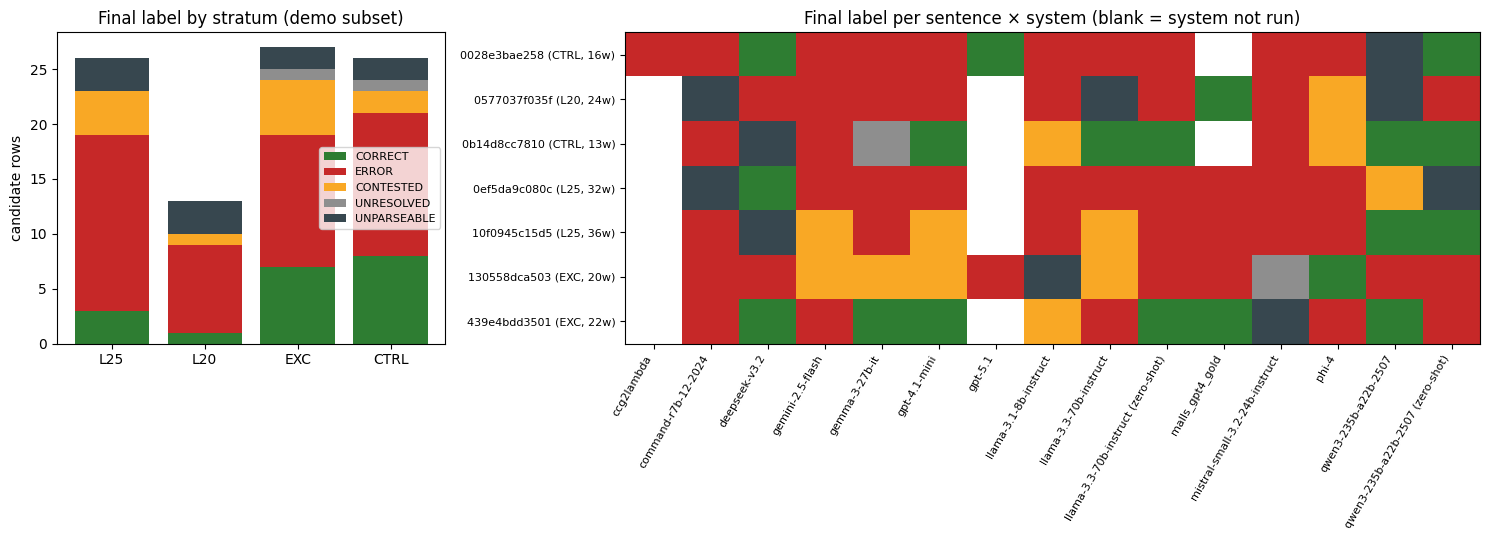

Tier counts (A = solver, B = panel-decided, C = no trusted reference, '-' = unparseable):
label  CONTESTED  CORRECT  ERROR  UNPARSEABLE  UNRESOLVED
tier                                                     
-              0        0      0           10           0
A              2        2      2            0           0
B              3        7     18            0           0
C              7       10     29            0           0
none           0        0      0            0           2


In [15]:
LABELS = ["CORRECT", "ERROR", "CONTESTED", "UNRESOLVED", "UNPARSEABLE"]
COLORS = {"CORRECT": "#2e7d32", "ERROR": "#c62828", "CONTESTED": "#f9a825", "UNRESOLVED": "#8e8e8e", "UNPARSEABLE": "#37474f"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 2.2]})
ct = df.groupby("stratum").label.value_counts().unstack(fill_value=0).reindex(columns=LABELS, fill_value=0).reindex(["L25", "L20", "EXC", "CTRL"])
bottom = np.zeros(len(ct))
for lab in LABELS:
    axes[0].bar(ct.index, ct[lab], bottom=bottom, color=COLORS[lab], label=lab)
    bottom += ct[lab].values
axes[0].set_title("Final label by stratum (demo subset)")
axes[0].set_ylabel("candidate rows")
axes[0].legend(fontsize=8)

grid = df.pivot_table(index="sentence_id", columns="system", values="label", aggfunc="first")
sent_order = df.drop_duplicates("sentence_id").set_index("sentence_id").loc[grid.index]
grid.index = [f"{s} ({st}, {w}w)" for s, st, w in zip(grid.index, sent_order.stratum, sent_order.words)]
code_map = {l: i for i, l in enumerate(LABELS)}
Z = grid.apply(lambda col: col.map(lambda v: code_map.get(v, np.nan))).to_numpy(dtype=float)
from matplotlib.colors import ListedColormap
axes[1].imshow(np.ma.masked_invalid(Z), cmap=ListedColormap([COLORS[l] for l in LABELS]), vmin=-0.5, vmax=len(LABELS) - 0.5, aspect="auto")
axes[1].set_xticks(range(grid.shape[1])); axes[1].set_xticklabels(grid.columns, rotation=60, ha="right", fontsize=8)
axes[1].set_yticks(range(grid.shape[0])); axes[1].set_yticklabels(grid.index, fontsize=8)
axes[1].set_title("Final label per sentence × system (blank = system not run)")
plt.tight_layout()
plt.show()

print("Tier counts (A = solver, B = panel-decided, C = no trusted reference, '-' = unparseable):")
print(df.groupby("tier").label.value_counts().unstack(fill_value=0).to_string())